# cGAN Training

### Goal - To build and train our **conditional GAN (cGAN)** - a generative model that learsn to create **synthetic handwriting images** conditioned on digit labels

## Plan 

1. Understand the architecture of a **conditional Gan (cGAN)**
2. Implement **Generator** and **discriminator** in pytorch
3. Train model with adversarial objectives
4. Visualise class-conditional handwriting samples

## Recap (cGAN)

A **Generative Adversarial Network (GAN)** consists of:
- A **Generator (G)** that creates fake samples from random noise.
- A **Discriminator (D)** that tries to tell real from fake.

In a **Conditional GAN**, both G and D receive an **additional input**: a *class label*.  
This allows the model to generate specific digits or characters on demand.

In [1]:
# import core libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np

import os, sys

from data_utils.dataloader import get_mnist_loaders
from model.cgan import Generator, Discriminator
from training.train_cgan import train_cgan
from utils.visualize import show_batch
from utils.checkpoint import save_checkpoint

device = (
    "cuda" if torch.cuda.is_available() 
    else "mps" if torch.backends.mps.is_available() 
    else "cpu"
)
print(f" Running on device: {device}")

 Running on device: mps


### Define Model Hyperparameters 


We’ll use a low-dimensional latent space (`z_dim = 100`),  
and condition the model on **10 digit classes (0–9)**.

GANs are notoriously sensitive to hyperparameters —  
we’ll start simple and iterate.

In [2]:
# hyperparameters 
z_dim = 100
num_classes = 10
img_shape = (1, 28, 28)
batch_size = 128
lr = 0.0002
epochs = 50

In [3]:
train_loader, test_loader = get_mnist_loaders(batch_size=batch_size)
print(f"Training batches: {len(train_loader)} | Test batches: {len(test_loader)}")

Training batches: 469 | Test batches: 79


Before we dive into training, let's define both our **Generator** and **Discriminator**.

Each will use the label embedding trick — where we turn the class label (e.g., “3”) into a learnable vector that can be concatenated with the noise or image input.

Our models are intentionally **lightweight** to make training on CPU/MPS feasible.  We’ll focus on the learning process and class conditioning rather than pixel-perfect realism.

In [4]:
generator = Generator(z_dim=z_dim, num_classes=num_classes, img_shape=img_shape).to(device)
discriminator = Discriminator(num_classes=num_classes, img_shape=img_shape).to(device)
optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))
criterion = nn.BCELoss()

## Training Strategy

We’ll alternate between training the **Discriminator (D)** and **Generator (G)**.

1. **Train D:**  
   - Use real images labeled as 1  
   - Use fake images (from G) labeled as 0  

2. **Train G:**  
   - Generate fake images  
   - Fool D into predicting them as 1  

This adversarial game continues until G generates *realistic*, class-conditioned digits.

The reusable `train_cgan` loop below applies the standard BCE objectives separately:  
$L_D = \tfrac{1}{2}[\mathrm{BCE}(D(x,y),1)+\mathrm{BCE}(D(G(z,y),y),0)]$ and  
$L_G = \mathrm{BCE}(D(G(z,y),y),1)$. Each loss is backpropagated through only its corresponding optimizer step.

In [5]:
history = train_cgan(
    generator, discriminator, train_loader, optimizer_G, optimizer_D,
    criterion, device, z_dim, num_classes, epochs=epochs,
    checkpoint_dir="../checkpoints", checkpoint_every=10,
)

[Epoch 1/50] D loss: 0.5191 | G loss: 1.0469


[Epoch 2/50] D loss: 0.4883 | G loss: 1.2433


[Epoch 3/50] D loss: 0.3763 | G loss: 1.2450


[Epoch 4/50] D loss: 0.3669 | G loss: 2.0978


[Epoch 5/50] D loss: 0.3667 | G loss: 1.6358


...

[Epoch 46/50] D loss: 0.6502 | G loss: 0.5287


[Epoch 47/50] D loss: 0.5411 | G loss: 1.5530


[Epoch 48/50] D loss: 0.3909 | G loss: 0.6149


[Epoch 49/50] D loss: 0.6023 | G loss: 1.4010


[Epoch 50/50] D loss: 0.3135 | G loss: 0.9731
Saved checkpoint: ../checkpoints/cgan_generator_epoch50.pt
Saved checkpoint: ../checkpoints/cgan_discriminator_epoch50.pt
Saved checkpoints at epoch 50
Saved checkpoint: ../checkpoints/cgan_generator_epochfinal.pt
Saved checkpoint: ../checkpoints/cgan_discriminator_epochfinal.pt


In [6]:
# train_cgan saves both final model and optimizer states automatically.
print("Final checkpoints saved in ../checkpoints")

Final checkpoints saved in ../checkpoints


### Note
Training GANs can be unstable.  
If losses oscillate, that’s expected — D and G are in constant competition.

Let’s visualize a few generated samples at the end of training to check if conditioning worked.

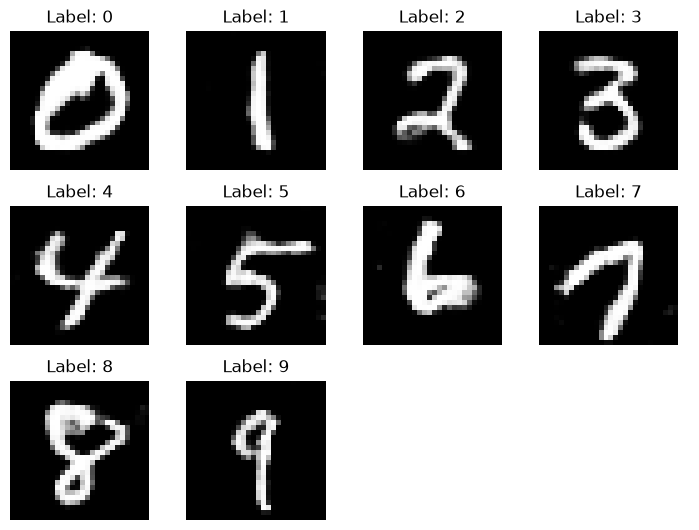

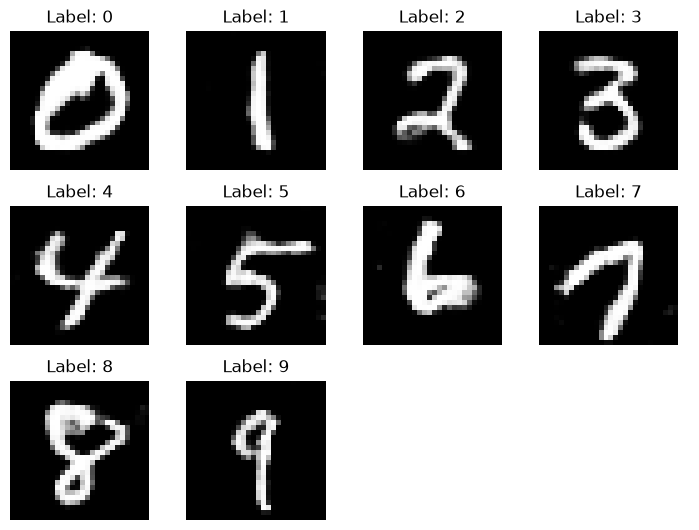

In [7]:
### Generate and visualize samples
def generate_samples(generator, n_classes=10, n_per_class=8):
    generator.eval()
    with torch.no_grad():
        z = torch.randn(n_classes * n_per_class, z_dim).to(device)
        labels = torch.tensor([i for i in range(n_classes) for _ in range(n_per_class)]).to(device)
        gen_imgs = generator(z, labels)
    generator.train()
    return gen_imgs, labels

# One conditioned sample for every digit ensures the grid explicitly covers 0-9.
gen_imgs, gen_labels = generate_samples(generator, n_per_class=1)
show_batch(gen_imgs.cpu(), gen_labels.cpu(), n=10)

We can now see grids of digits 0–9, each set showing several synthetic examples.  
Each class label corresponds to the digit the Generator was conditioned on.

Even if the images look a bit fuzzy, the model has learned the *concept* of conditioning —  
the generator “knows” which class to produce.